In [1]:
# Plotting the confusion matrix with top-1 approach for all 54 classes
# select "env" to get evaluation only on environmental images
# else select "ref" for confusion matrix evaluated on all images (reference and environmental)


In [1]:
import pickle
import numpy as np
import seaborn as sns

import matplotlib.colors as mcolors
from matplotlib import gridspec
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
from config1 import CLASSIFICATION_DATA, get_predictions_classes, classes54


In [3]:
p_model_outputs = CLASSIFICATION_DATA / "4.MODEL_PREDICTIONS"



In [ ]:

classes54ordered = ['QuercusDeciduous', 'QuercusIlex', 'Buxus', 'Phillyrea',  'FraxinusExcelsior', 'FraxinusOrnus',  'Olea',  'Cupressaceae',  'Pistacia',  'Poaceae','Plantago', 
          'VitisF', 'VitisS', 'Pinaceae', 
          'Acacia', 'Acer', 'Alnus', 'Amarantaceae', 'Artemisia', 'Betulaceae', 'Brassicaceae',  'Carduus', 'Caryophyllaceae', 'Cichorioideae',  'Cyperaceae', 'Echium', 'Ericaceae', 'Fagus',  'Gallium',
          'Juglans', 'Lamiaceae', 'Liliaceae', 'Moraceae', 'Morphotype1', 'Morphotype2', 'Myrtaceae',  'Platanus',  'PopulusSp','Ranunculaceae', 'Rhamnus', 'Rosaceae', 'Rumex', 'Salix', 'Sanguisorba', 'Tilia', 'Ulmus', 'Urtica', 'ViburnumSambucusTp', 'XanthiumAmbrosia',
          'Other', 'IndetCovered',  'IndetBlurry','NonPollen', 'Lycopodium']


classes54ordered_it = [ '$\\it{Quercus~deciduous}$', '$\\it{Quercus~ilex}$', '$\\it{Buxus}$', '$\\it{Phillyrea}$','$\\it{Fraxinus~excelsior}$', '$\\it{Fraxinus~ornus}$',
                 '$\\it{Olea}$', 'Cupressaceae',  '$\\it{Pistacia}$',  'Poaceae', '$\\it{Plantago}$', '$\\it{Vitis}$ fertile', '$\\it{Vitis}$ sterile',  'Pinaceae', 
                '$\\it{Acacia}$', '$\\it{Acer}$', '$\\it{Alnus}$', 'Amarantaceae', '$\\it{Artemisia}$', '$\\it{Betulaceae}$', 'Brassicaceae',
                '$\\it{Carduus}$', 'Caryophyllaceae', 'Cichorioideae',  'Cyperaceae', '$\\it{Echium}$', 'Ericaceae', '$\\it{Fagus}$', 
                '$\\it{Galium}$', '$\\it{Juglans}$', 'Lamiaceae', 'Liliaceae',  'Moraceae', 'Morphotype 1', 'Morphotype 2',
                'Myrtaceae',  '$\\it{Platanus}$', '$\\it{Populus}$', 'Ranunculaceae', '$\\it{Rhamnus}$', 'Rosaceae', '$\\it{Rumex}$', 
                '$\\it{Salix}$', '$\\it{Sanguisorba}$', '$\\it{Tilia}$', '$\\it{Ulmus}$', '$\\it{Urtica}$', '$\\it{Viburnum / Sambucus}$',  '$\\it{Xanthium / Ambrosia}$',
                'Other', 'Indeterminate (covered)', 'Indeterminate (blurry)', 'Non-pollen', '$\\it{Lycopodium}$'
                ] 


In [5]:
true_all=[]
pred_all=[]
filename_all=[]

for idx in [1,2,3,4,5,6,7,8,9,10]:
    cval_id = f'fold{idx}'

    true, pred, filenames = get_predictions_classes(cval_id, p_model_outputs, classes54, envref="ref") #env or ref)
    true_all+=true
    pred_all+=pred
print(len(pred_all))


51686


In [6]:
blues = plt.get_cmap('Greys')
colors = [blues(i) for i in np.linspace(0, 0.1, 65)]
colors += [blues(i) for i in np.linspace(0.1, 1, 35)]
new_cmap = mcolors.LinearSegmentedColormap.from_list("custom_blues", colors, N=100)

/tmp/ipykernel_17513/797961529.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


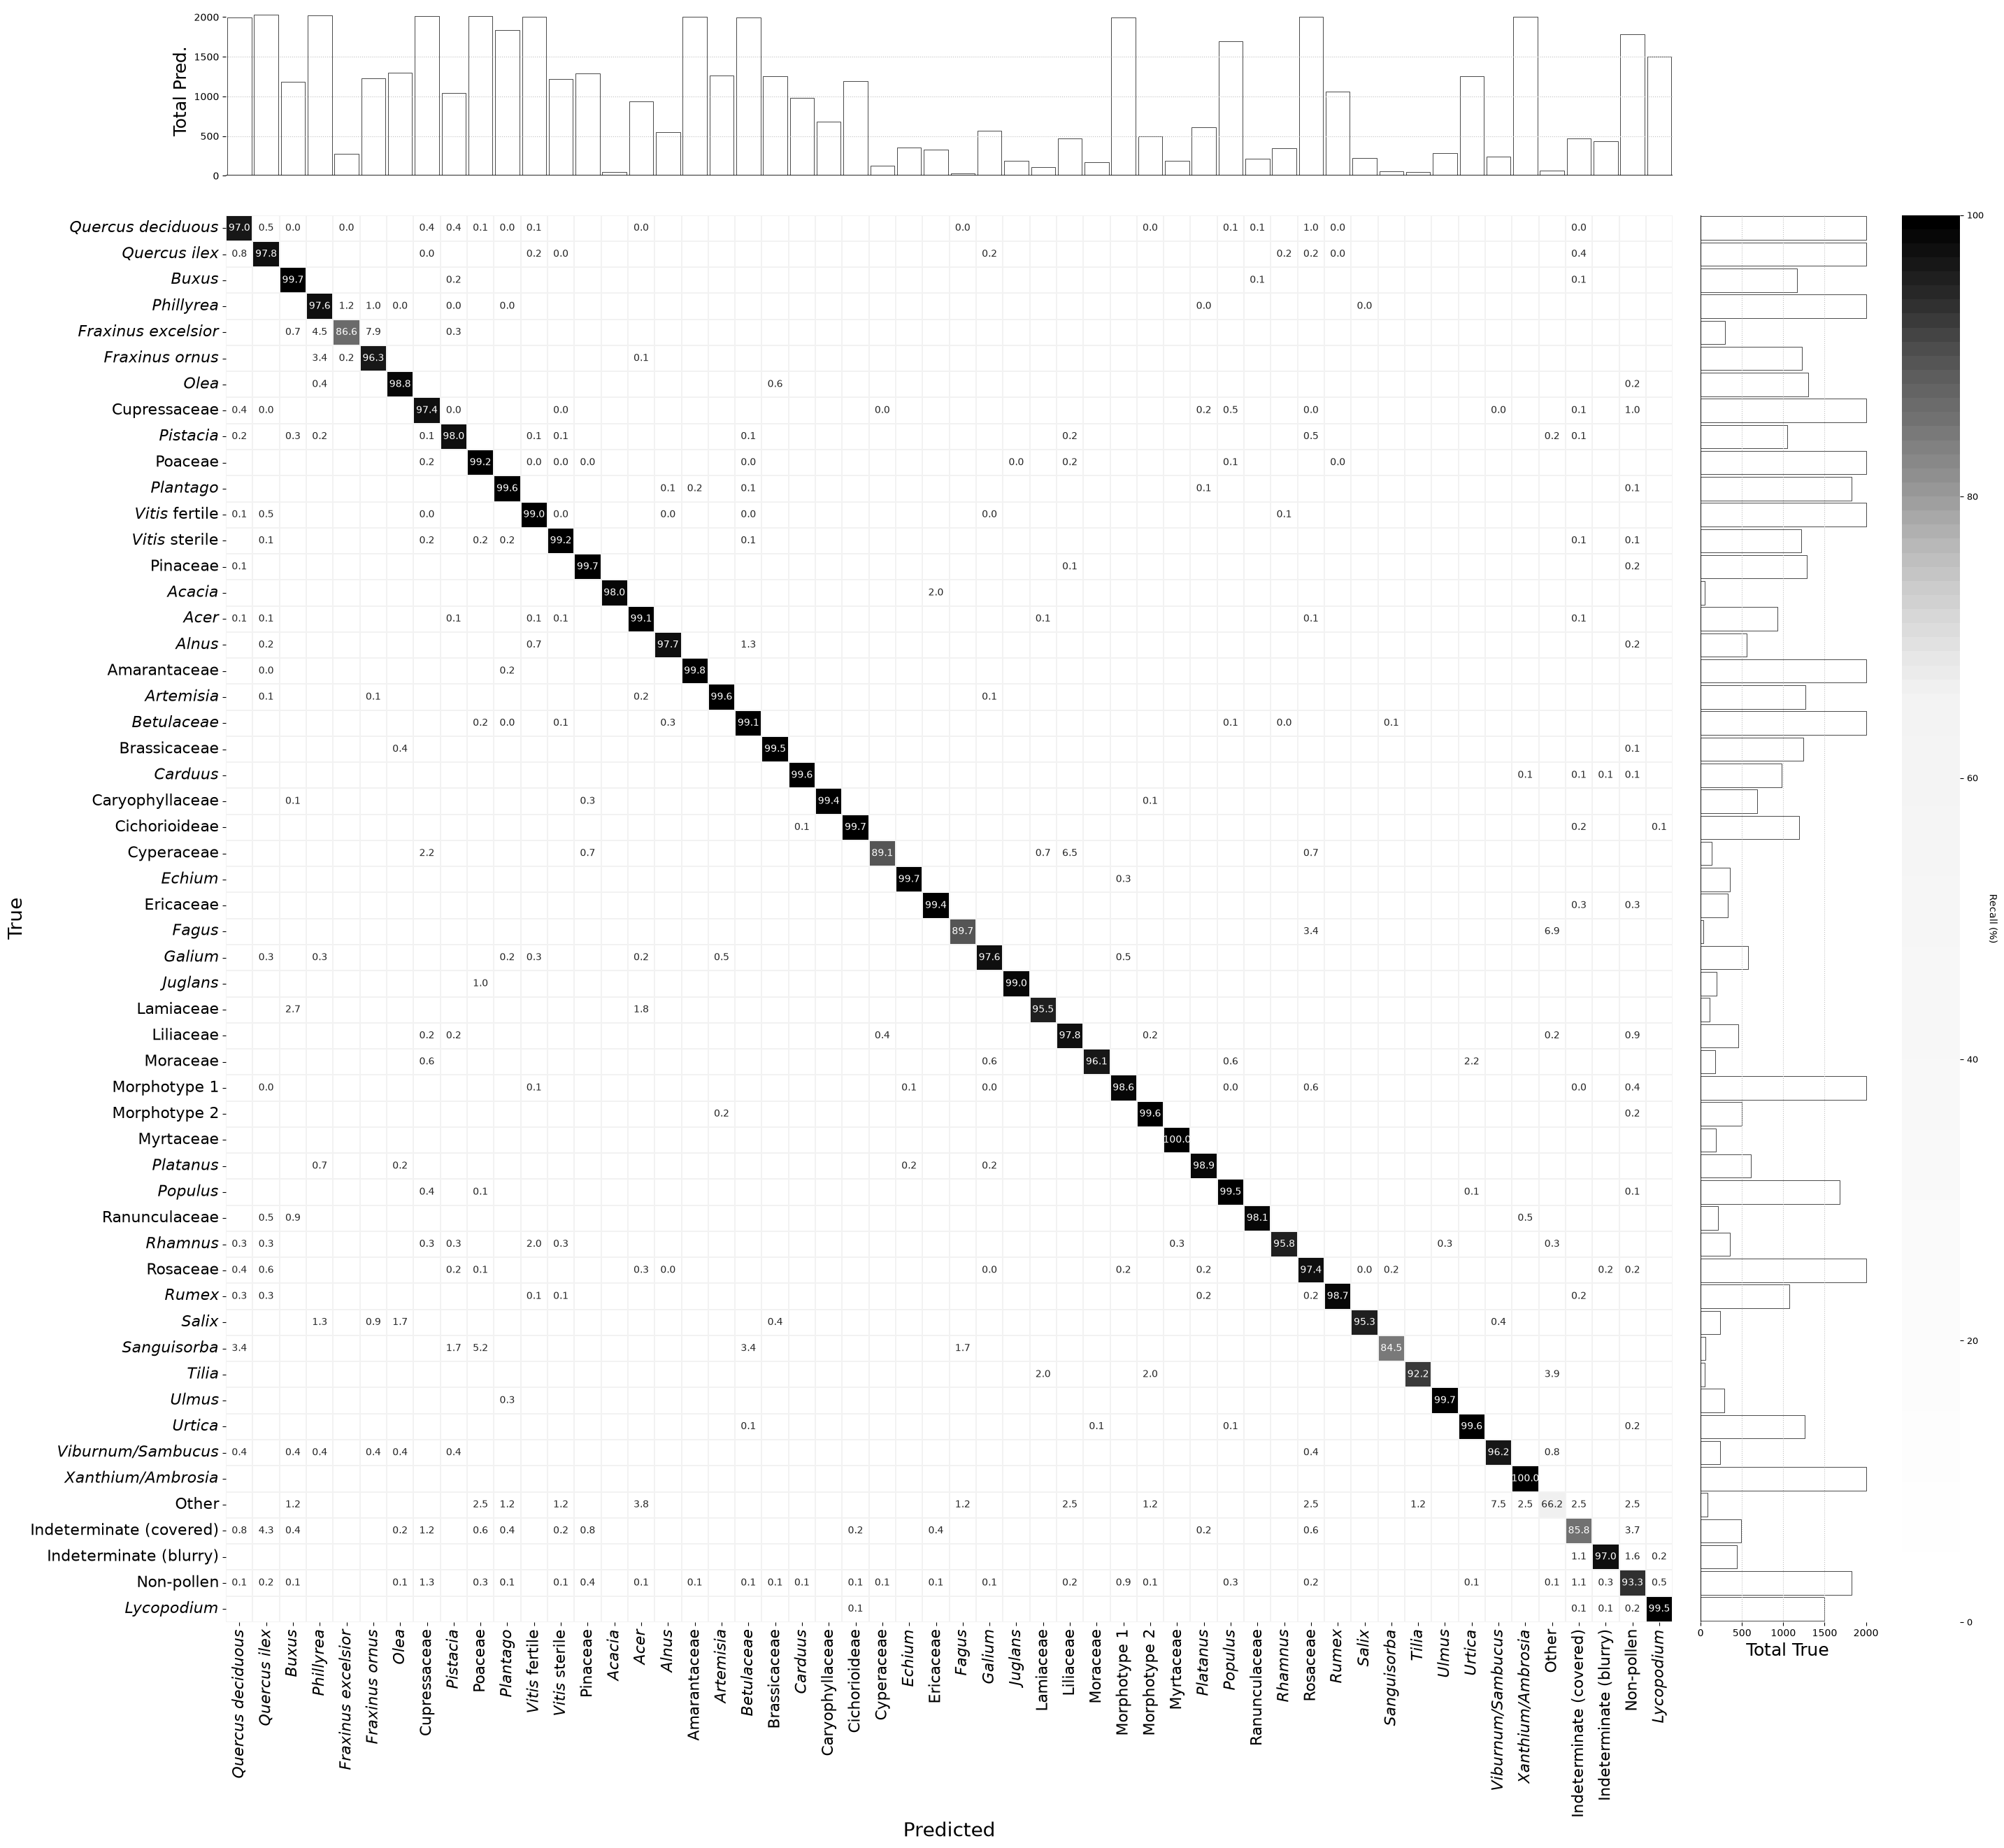

In [ ]:

cm = confusion_matrix(true_all, pred_all, labels=classes54ordered)
cm_normalized = 100*cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sx=32
sy=30
cm_total_true = cm.sum(axis=1)
cm_total_pred = cm.sum(axis=0)

fig = plt.figure(figsize=(sx, sy))
gs = gridspec.GridSpec(
    2, 3, 
    width_ratios=[10, 1.2, 0.4],
    height_ratios=[1.2, 10],
    wspace=0.05, hspace=0.05
)

ax_main = plt.subplot(gs[1, 0])
ax_right = plt.subplot(gs[1, 1], sharey=ax_main)
ax_top = plt.subplot(gs[0, 0], sharex=ax_main)
ax_cbar = plt.subplot(gs[1, 2])  

annot_vals = np.where(cm < 0.1, "", np.round(cm_normalized, 1).astype(str))

annot_vals[cm == 0] = "" 

sns.heatmap(
    cm_normalized,
    annot=annot_vals, 
    fmt='', 
    cmap=new_cmap,
    xticklabels=classes54ordered_it,
    yticklabels=classes54ordered_it,
    cbar=True,
    linewidths=0.1,      
    linecolor='#f2f2f2', 
    vmin=0,
    vmax=100,
    ax=ax_main,
    cbar_ax=ax_cbar
)
ax_main.set_xticklabels(labels=classes54ordered_it, fontsize=16)
ax_main.set_yticklabels(labels=classes54ordered_it, fontsize=16)
ax_main.set_xlabel('Predicted', fontsize=20)
ax_main.set_ylabel('True', fontsize=20)
ax_main.set_title('')

x_positions =  np.arange(len(cm_total_pred)) + 0.5 
ax_top.bar(x_positions, cm_total_pred, color='white', width=0.9, edgecolor='black',linewidth=0.5, ) 
ax_top.set_ylabel("Total Pred.", fontsize=18)
ax_top.tick_params(axis='x', bottom=False, labelbottom=False)
ax_top.axhline(500, color='silver', linestyle=':', linewidth=0.8)
ax_top.axhline(1000, color='silver', linestyle=':', linewidth=0.8)
ax_top.axhline(1500, color='silver', linestyle=':', linewidth=0.8)
ax_top.axhline(0, color='black', linestyle='-', linewidth=1.2)
ax_top.grid(False)
sns.despine(ax=ax_top, left=True, bottom=True)

y_positions = np.arange(len(cm_total_true)) + 0.5
ax_right.barh(y_positions, cm_total_true, color='white', height=0.9, edgecolor='black',linewidth=0.5, )  # silver
ax_right.set_xlabel("Total True", fontsize=18)
ax_right.tick_params(axis='y', left=False, labelleft=False)
ax_right.axvline(500, color='silver', linestyle=':', linewidth=0.8)
ax_right.axvline(1000, color='silver', linestyle=':', linewidth=0.8)
ax_right.axvline(1500, color='silver', linestyle=':', linewidth=0.8)
ax_right.axvline(0, color='black', linestyle='-', linewidth=1.2)
ax_right.grid(False)
sns.despine(ax=ax_right, left=True, bottom=True)

ax_cbar.set_ylabel("Recall (%)", rotation=-90, va="bottom")
ax_cbar.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(CLASSIFICATION_DATA / "FigApp_A4-A5.pdf",  bbox_inches="tight") # figure A4 or A5 depending if only env images are considered or both env and ref images
plt.show()

